# Week 2 – Day 3: Full Regression Workflow, Evaluation Metrics & Residual Analysis

## 1) Introduction
Day 3 completes the Week 2 regression workflow.

Workflow for today:
**Dataset -> Features/Target -> Split -> Preprocessing -> Train Models -> Evaluate -> Residual Analysis -> Overfitting Reflection**

The goal is not only to train models, but also to interpret prediction errors and understand model behavior.

## 2) Import Libraries
We use these libraries and methods throughout the Day 3 practical.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

### What these imports do and why they are used
- `pandas`, `numpy`: data handling and numerical operations.
- `matplotlib.pyplot`: plots for model comparison and residual analysis.
- `train_test_split`: creates training and test sets.
- `cross_val_score`, `KFold`: cross-validation performance checks.
- `SimpleImputer`: fills missing values.
- `OneHotEncoder`: converts categorical values into numeric columns.
- `StandardScaler`: scales numerical features.
- `PolynomialFeatures`: creates squared and interaction terms.
- `ColumnTransformer`: applies preprocessing by feature type.
- `Pipeline`: chains preprocessing and model steps safely.
- `LinearRegression`, `Ridge`, `Lasso`: regression models for comparison.
- `mean_absolute_error`, `mean_squared_error`, `r2_score`: evaluation metrics used in this notebook.

## 3) Load or Create Dataset
We load the Day 1 dataset from `data/week2/day1_house_energy_sample.csv`.
If it is missing, we create a synthetic dataset (~150 rows), save it, and continue.

In [2]:
dataset_path = '../../data/week2/day1_house_energy_sample.csv'
os.makedirs('../../data/week2', exist_ok=True)

if not os.path.exists(dataset_path):
    rng = np.random.default_rng(42)
    n = 150

    house_size_m2 = np.clip(rng.normal(135, 48, n), 40, 460)
    bedrooms = np.clip(np.round(house_size_m2 / 35 + rng.normal(0, 1.0, n)), 1, 8).astype(int)
    building_age_years = np.clip(rng.normal(31, 22, n), 1, 120)
    city = rng.choice(['Berlin', 'Munich', 'Hamburg', 'Cologne', 'Leipzig'], n, p=[0.25, 0.2, 0.2, 0.2, 0.15])
    heating_type = rng.choice(['Gas', 'Electric', 'Heat Pump', 'District'], n, p=[0.38, 0.25, 0.22, 0.15])
    insulation_grade = rng.choice(['A', 'B', 'C', 'D'], n, p=[0.18, 0.35, 0.3, 0.17])
    average_temperature_c = np.clip(rng.normal(10.5, 5, n), -7, 24)

    insulation_effect = pd.Series(insulation_grade).map({'A': -1300, 'B': -650, 'C': 180, 'D': 1050}).to_numpy()
    heating_effect = pd.Series(heating_type).map({'Heat Pump': -850, 'District': -300, 'Gas': 220, 'Electric': 520}).to_numpy()
    city_effect = pd.Series(city).map({'Berlin': 120, 'Munich': 260, 'Hamburg': 150, 'Cologne': 90, 'Leipzig': -40}).to_numpy()
    noise = rng.normal(0, 420, n)

    energy_consumption_kwh = (
        3600
        + 23 * house_size_m2
        + 15 * building_age_years
        + (14 - average_temperature_c) * 175
        + insulation_effect
        + heating_effect
        + city_effect
        + noise
    )
    energy_consumption_kwh = np.clip(energy_consumption_kwh, 1500, None)

    df_generated = pd.DataFrame({
        'house_size_m2': house_size_m2.round(1),
        'bedrooms': bedrooms,
        'building_age_years': building_age_years.round(1),
        'city': city,
        'heating_type': heating_type,
        'insulation_grade': insulation_grade,
        'average_temperature_c': average_temperature_c.round(1),
        'energy_consumption_kwh': energy_consumption_kwh.round(1),
    })

    # Add missing values
    for col in ['house_size_m2', 'building_age_years', 'average_temperature_c']:
        idx = rng.choice(df_generated.index, size=5, replace=False)
        df_generated.loc[idx, col] = np.nan

    for col in ['city', 'heating_type', 'insulation_grade']:
        idx = rng.choice(df_generated.index, size=4, replace=False)
        df_generated.loc[idx, col] = np.nan

    # Add outliers
    df_generated.loc[3, ['house_size_m2', 'energy_consumption_kwh']] = [520, 34000]
    df_generated.loc[55, ['building_age_years', 'energy_consumption_kwh']] = [140, 28000]
    df_generated.loc[103, ['average_temperature_c', 'energy_consumption_kwh']] = [-18, 30000]

    df_generated.to_csv(dataset_path, index=False)
    print('Dataset was missing. Synthetic dataset created at:', dataset_path)

df = pd.read_csv(dataset_path)
print('Loaded dataset:', dataset_path)

Loaded dataset: data/week2/day1_house_energy_sample.csv


We use the standard first-look methods:
- `df.head()` for preview
- `df.shape` for size
- `df.info()` for column types and missing values
- `df.describe()` for summary statistics

In [3]:
display(df.head())
print('Shape:', df.shape)
print('\nInfo:')
df.info()
print('\nDescribe:')
display(df.describe())

,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,149.6,4,68.0,Hamburg,Gas,C,8.3,9367.1
1,85.1,1,1.0,Munich,Heat Pump,B,-2.0,7471.7
2,171.0,3,49.0,Hamburg,Electric,C,2.0,11506.6
3,520.0,5,22.8,Berlin,District,C,6.3,34000.0
4,41.4,1,28.7,Berlin,Electric,D,NaN,8180.4


Shape: (150, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   house_size_m2           145 non-null    float64
 1   bedrooms                150 non-null    int64  
 2   building_age_years      145 non-null    float64
 3   city                    146 non-null    object 
 4   heating_type            146 non-null    object 
 5   insulation_grade        146 non-null    object 
 6   average_temperature_c   145 non-null    float64
 7   energy_consumption_kwh  150 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 9.5+ KB

Describe:


,house_size_m2,bedrooms,building_age_years,average_temperature_c,energy_consumption_kwh
count,145.000000,150.000000,145.000000,145.000000,150.000000
mean,135.731034,3.786667,32.541379,10.260000,8121.080000
std,52.046221,1.599441,21.948762,5.432188,3630.489948
min,40.000000,1.000000,1.000000,-18.000000,3726.700000
25%,104.300000,3.000000,15.200000,8.000000,6392.475000
50%,135.600000,4.000000,33.000000,10.800000,7533.100000
75%,161.100000,5.000000,47.700000,13.300000,8704.975000
max,520.000000,8.000000,140.000000,21.700000,34000.000000


## 4) Define the Regression Task
We want to predict `energy_consumption_kwh`. This is a regression problem because the target is continuous (numerical).

In [4]:
target = 'energy_consumption_kwh'
X = df.drop(columns=[target])
y = df[target]

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (150, 7)
y shape: (150,)


- `X` = input features
- `y` = target values
- regression predicts numerical outputs

## 5) Define Feature Groups
We split features by type so preprocessing is applied correctly.

In [5]:
numerical_features = [
    'house_size_m2',
    'bedrooms',
    'building_age_years',
    'average_temperature_c'
]

categorical_features = [
    'city',
    'heating_type',
    'insulation_grade'
]

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)

Numerical features: ['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']
Categorical features: ['city', 'heating_type', 'insulation_grade']


- numerical features: need imputation and scaling
- categorical features: need imputation and encoding

## 6) Train-Test Split
Training data is used to fit models. Test data is used to check generalization.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (120, 7)
X_test shape: (30, 7)


Test data should not guide training decisions. It is used only for final evaluation.

## 7) Data Leakage Reminder
Preprocessing must be fitted only on training data, then applied to test data.

Leakage examples:
- scaling before splitting
- imputing missing values using full dataset
- selecting features using full dataset
- creating features from target values

## 8) Build Preprocessing Pipeline
We define separate pipelines and combine them with `ColumnTransformer`.

In [7]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

print('Preprocessor is ready.')

Preprocessor is ready.


- `SimpleImputer`: fills missing values (`median` for numeric, `most_frequent` for categorical).
- `StandardScaler`: standardizes numerical feature ranges.
- `OneHotEncoder`: converts category values to numeric indicator columns.
- `ColumnTransformer`: sends each feature group through the right steps.
- `Pipeline`: safely chains transformations and model training.

## 9) Helper Function for Model Evaluation
This function fits a model, predicts train/test outputs, and returns MAE, MSE, RMSE, and R².

In [8]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Fit model on training data
    model.fit(X_train, y_train)

    # Predictions for train and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Core errors
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # RMSE compatibility across sklearn versions
    try:
        train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
        test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
    except TypeError:
        train_rmse = np.sqrt(train_mse)
        test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return {
        'Model': model_name,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'y_test_pred': y_test_pred
    }

Metric meaning:
- **MAE**: average absolute error size.
- **MSE**: average squared error, penalizes large errors more strongly.
- **RMSE**: square root of MSE, easier to interpret in original target units.
- **R²**: fraction of target variance explained by the model (higher is better).

## 10) Model 1: Simple Linear Regression
Simple linear regression uses one feature to predict one continuous target.
Here we use only `average_temperature_c`.

Simple model test RMSE: 4249.09


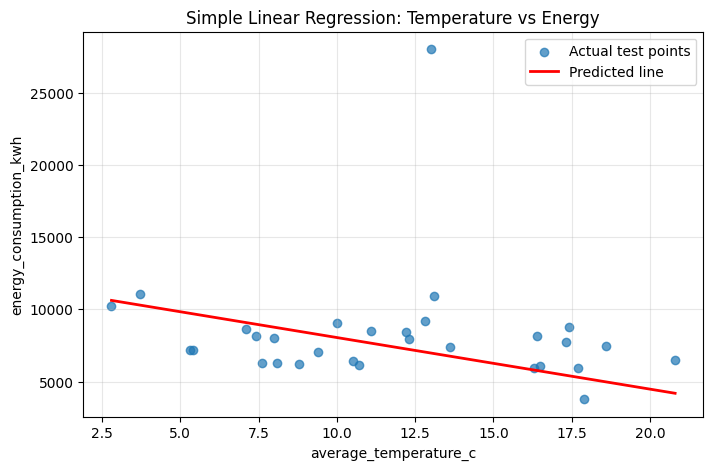

In [9]:
X_simple = X[['average_temperature_c']]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

simple_results = evaluate_model(
    'Simple Linear Regression',
    simple_pipeline,
    X_train_s, X_test_s, y_train_s, y_test_s
)

print('Simple model test RMSE:', round(simple_results['Test RMSE'], 2))

# Plot simple linear fit
simple_pipeline.fit(X_train_s, y_train_s)
x_plot = X_test_s.copy()
x_plot['y_actual'] = y_test_s.values
x_plot['y_pred'] = simple_pipeline.predict(X_test_s)
x_plot = x_plot.sort_values('average_temperature_c')

plt.figure(figsize=(8, 5))
plt.scatter(X_test_s['average_temperature_c'], y_test_s, alpha=0.7, label='Actual test points')
plt.plot(x_plot['average_temperature_c'], x_plot['y_pred'], color='red', linewidth=2, label='Predicted line')
plt.xlabel('average_temperature_c')
plt.ylabel('energy_consumption_kwh')
plt.title('Simple Linear Regression: Temperature vs Energy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11) Model 2: Multiple Linear Regression
Multiple linear regression uses several input features to predict one continuous target.

In [10]:
multiple_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

multiple_results = evaluate_model(
    'Multiple Linear Regression',
    multiple_model,
    X_train, X_test, y_train, y_test
)

print('Multiple model test RMSE:', round(multiple_results['Test RMSE'], 2))

Multiple model test RMSE: 3518.38


## 12) Model 3: Polynomial Regression
Polynomial regression adds squared and interaction terms to capture curved relationships.

For clarity, we apply it to two numerical features: `average_temperature_c` and `house_size_m2`.

In [11]:
poly_features = ['average_temperature_c', 'house_size_m2']
X_poly = X[poly_features]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly_results = evaluate_model(
    'Polynomial Regression (degree=2)',
    poly_pipeline,
    X_train_p, X_test_p, y_train_p, y_test_p
)

print('Polynomial model test RMSE:', round(poly_results['Test RMSE'], 2))

Polynomial model test RMSE: 4078.47


Polynomial features can improve fit, but they may also increase overfitting risk if the model becomes too complex.

## 13) Model 4: Ridge Regression
Ridge uses L2 regularization to shrink coefficients and improve stability.

In [12]:
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_results = evaluate_model(
    'Ridge Regression',
    ridge_model,
    X_train, X_test, y_train, y_test
)

print('Ridge model test RMSE:', round(ridge_results['Test RMSE'], 2))

Ridge model test RMSE: 3533.52


## 14) Model 5: Lasso Regression
Lasso uses L1 regularization and can set some coefficients exactly to zero.

In [13]:
lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1, max_iter=10000))
])

lasso_results = evaluate_model(
    'Lasso Regression',
    lasso_model,
    X_train, X_test, y_train, y_test
)

print('Lasso model test RMSE:', round(lasso_results['Test RMSE'], 2))

Lasso model test RMSE: 3518.59


## 15) Compare All Models
Lower MAE/RMSE is better. Higher R² is better.
A large train-test gap can indicate overfitting.

In [14]:
all_results = [simple_results, multiple_results, poly_results, ridge_results, lasso_results]

results_df = pd.DataFrame([{
    'Model': r['Model'],
    'Train MAE': r['Train MAE'],
    'Test MAE': r['Test MAE'],
    'Train RMSE': r['Train RMSE'],
    'Test RMSE': r['Test RMSE'],
    'Train R2': r['Train R2'],
    'Test R2': r['Test R2']
} for r in all_results])

results_df = results_df.sort_values('Test RMSE', ascending=True).reset_index(drop=True)
display(results_df.round(3))

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Multiple Linear Regression,1007.588,1271.483,1565.247,3518.383,0.802,0.217
1,Lasso Regression,1007.499,1271.375,1565.247,3518.590,0.802,0.217
2,Ridge Regression,994.769,1259.457,1566.567,3533.517,0.802,0.211
3,Polynomial Regression (degree=2),1050.915,1595.534,1376.561,4078.474,0.847,-0.052
4,Simple Linear Regression,1483.911,2223.122,2946.869,4249.093,0.300,-0.142


## 16) Visual Model Comparison
We compare models using test RMSE and test R².

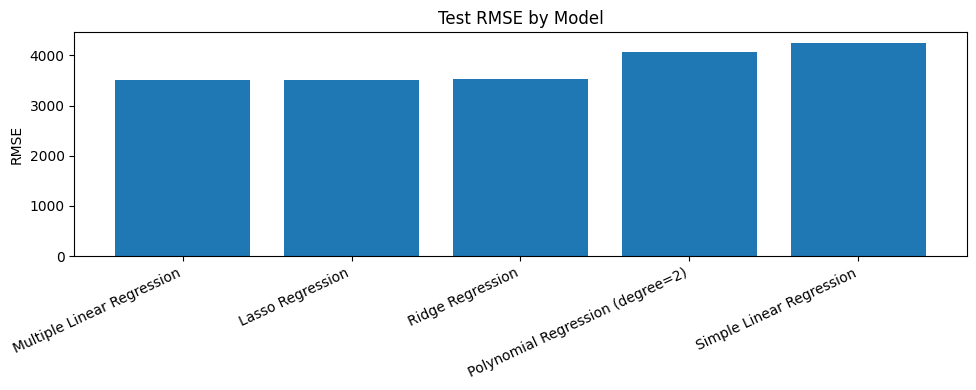

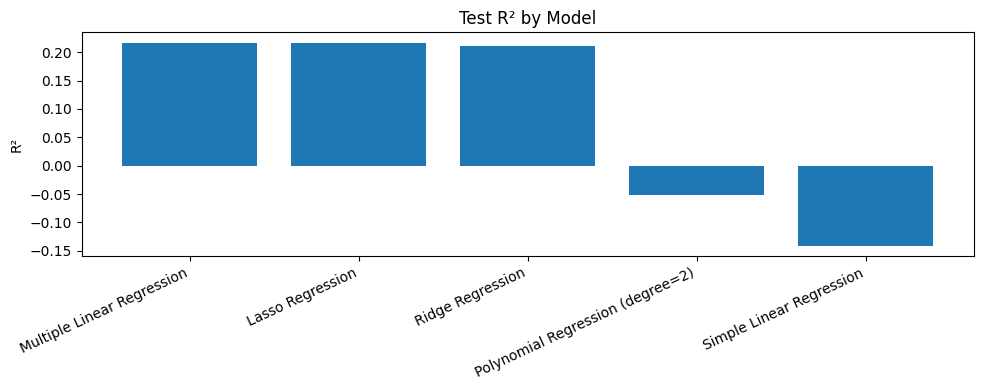

In [15]:
plt.figure(figsize=(10, 4))
plt.bar(results_df['Model'], results_df['Test RMSE'])
plt.title('Test RMSE by Model')
plt.ylabel('RMSE')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results_df['Model'], results_df['Test R2'])
plt.title('Test R² by Model')
plt.ylabel('R²')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

- lower RMSE means smaller prediction error
- higher R² means more variance explained

## 17) Actual vs Predicted Plot (Best Model)
We select the best model using the lowest test RMSE.

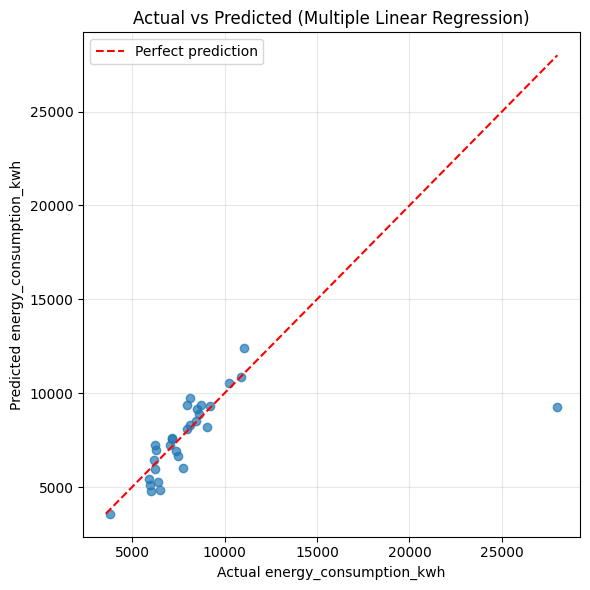

In [16]:
best_model_name = results_df.iloc[0]['Model']

result_map = {
    'Simple Linear Regression': simple_results,
    'Multiple Linear Regression': multiple_results,
    'Polynomial Regression (degree=2)': poly_results,
    'Ridge Regression': ridge_results,
    'Lasso Regression': lasso_results
}

best_result = result_map[best_model_name]
y_pred_best = best_result['y_test_pred']

# Choose matching y_test depending on model input
if best_model_name == 'Simple Linear Regression':
    y_test_best = y_test_s
elif best_model_name == 'Polynomial Regression (degree=2)':
    y_test_best = y_test_p
else:
    y_test_best = y_test

plt.figure(figsize=(6, 6))
plt.scatter(y_test_best, y_pred_best, alpha=0.7)

line_min = min(y_test_best.min(), y_pred_best.min())
line_max = max(y_test_best.max(), y_pred_best.max())
plt.plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual energy_consumption_kwh')
plt.ylabel('Predicted energy_consumption_kwh')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Points close to the diagonal line indicate better predictions.

## 18) Residual Analysis
Residuals are: `actual - predicted`.
A good residual pattern is usually random around zero.

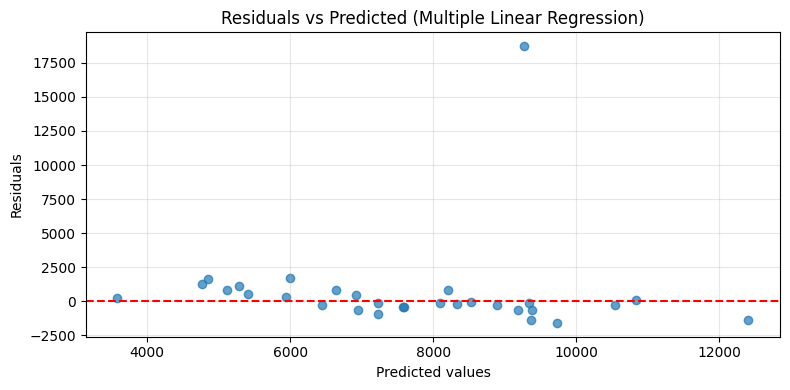

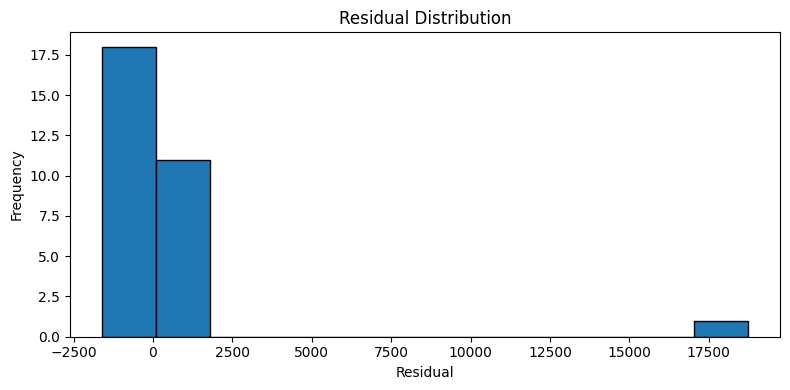

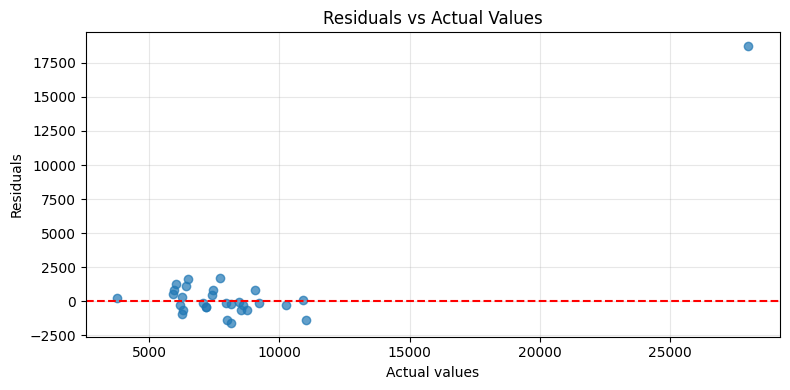

In [17]:
residuals = y_test_best - y_pred_best

# Residuals vs predicted
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_best, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title(f'Residuals vs Predicted ({best_model_name})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=12, edgecolor='black')
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Residuals vs actual
plt.figure(figsize=(8, 4))
plt.scatter(y_test_best, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual values')
plt.ylabel('Residuals')
plt.title('Residuals vs Actual Values')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Residual pattern hints:
- random around zero: model is reasonably specified
- curved pattern: linear model may be too simple
- increasing spread: unequal error variance
- isolated large points: possible outliers
- clear structure: missing features or wrong model form

## 19) Overfitting and Underfitting Reflection
Use train and test metrics to reflect on model behavior.

Possible **overfitting**:
- training error low
- test error high
- training R² much higher than test R²

Possible **underfitting**:
- training error high
- test error high
- model too simple

Student reflection questions:
- Which model seems best?
- Is there evidence of overfitting?
- Is there evidence of underfitting?
- How could the model be improved?

## 20) Cross-Validation Check
Cross-validation provides a more stable estimate than a single split.

In [18]:
model_pipeline_map = {
    'Simple Linear Regression': simple_pipeline,
    'Multiple Linear Regression': multiple_model,
    'Polynomial Regression (degree=2)': poly_pipeline,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model
}

best_pipeline = model_pipeline_map[best_model_name]
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Required scoring from prompt; fallback for older sklearn
try:
    cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error')
    cv_rmse_scores = -cv_scores
except ValueError:
    cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
    cv_rmse_scores = np.sqrt(-cv_scores)

cv_rmse_mean = cv_rmse_scores.mean()
cv_rmse_std = cv_rmse_scores.std()

print('RMSE for each fold:', np.round(cv_rmse_scores, 2))
print(f'Mean RMSE: {cv_rmse_mean:.2f}')
print(f'Standard deviation: {cv_rmse_std:.2f}')

RMSE for each fold: [4926.99 1716.9  1342.36 1449.89 1017.85]
Mean RMSE: 2090.80
Standard deviation: 1435.68


## 21) Optional Short Note: Logistic Regression
Logistic regression appears in Day 3 slides, but it is mainly a **classification** method.
It predicts probabilities and class labels, not continuous numerical values.
So it is not part of the main regression modeling workflow in this notebook.

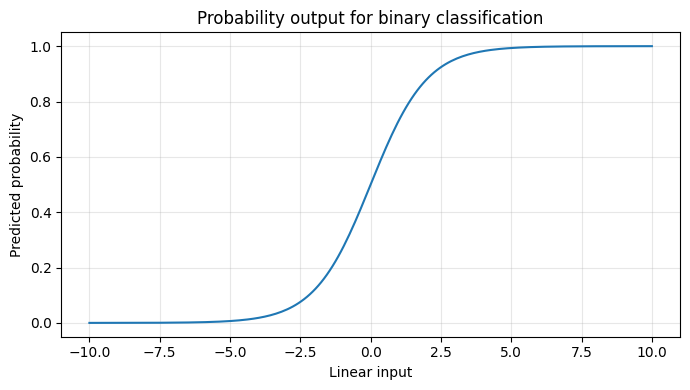

In [19]:
# Optional mini-visualization: sigmoid curve used in logistic regression
x_sigmoid = np.linspace(-10, 10, 200)
y_sigmoid = 1 / (1 + np.exp(-x_sigmoid))

plt.figure(figsize=(7, 4))
plt.plot(x_sigmoid, y_sigmoid)
plt.title('Probability output for binary classification')
plt.xlabel('Linear input')
plt.ylabel('Predicted probability')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 22) Final Week 2 Notebook Task
### Notebook 2 Individual – Regression Workflow
Students must complete:
1. Use a regression dataset
2. Define `X` and `y`
3. Split data correctly
4. Apply preprocessing using a pipeline
5. Train a baseline regression model
6. Train at least one improved model
7. Evaluate using MAE, MSE, RMSE, and R²
8. Compare models
9. Plot residuals
10. Interpret error patterns
11. Reflect on overfitting or underfitting

## 23) Final Output
We print the final Day 3 completion summary.

In [20]:
print('Week 2 Day 3 full regression workflow completed successfully.')
print('Best model name:', best_model_name)
print('Best model Test RMSE:', round(best_result['Test RMSE'], 2))
print('Best model Test R²:', round(best_result['Test R2'], 3))
print('Cross-validation mean RMSE:', round(cv_rmse_mean, 2))

print('\nResidual interpretation template:')
print('- Are residuals roughly centered around zero?')
print('- Do residuals show random spread or a clear pattern?')
print('- Are there large isolated residuals (possible outliers)?')
print('- What improvement would you test next?')

Week 2 Day 3 full regression workflow completed successfully.
Best model name: Multiple Linear Regression
Best model Test RMSE: 3518.38
Best model Test R²: 0.217
Cross-validation mean RMSE: 2090.8

Residual interpretation template:
- Are residuals roughly centered around zero?
- Do residuals show random spread or a clear pattern?
- Are there large isolated residuals (possible outliers)?
- What improvement would you test next?
